STUDENT PLACEMENT DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore Internship Branch  \
0   6.2             45              40                  50         No    CSE   
1   6.5             50              45                  52         No    ECE   
2   6.8             52              48                  55         No    CSE   
3   7.0             55              52                  58        Yes     IT   
4   7.2             58              55                  60         No    ECE   

  PlacementStatus  
0      Not Placed  
1      Not Placed  
2      Not Placed  
3          Placed  
4      Not Placed  

Dataset Shape:
(30, 7)

FEATURE TYPES
Numerical:
['CGPA', 'AptitudeScore', 'TechnicalScore', 'CommunicationScore']

Categorical:
['Internship', 'Branch']

TRAIN / VALIDATION SPLIT
Training samples: 24
Validation samples: 6

Number of transformed features: 9


ADABOOST
Train Accuracy: 1.0
Validation Accuracy: 1.0

Classification Report:
              precision    recall 

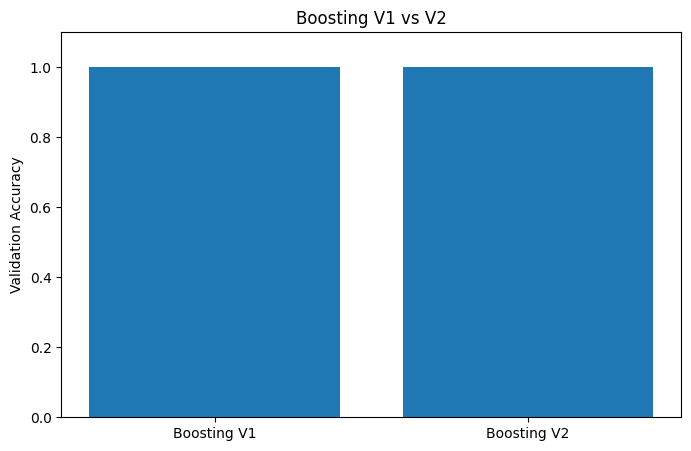



SHAP BEESWARM PLOT


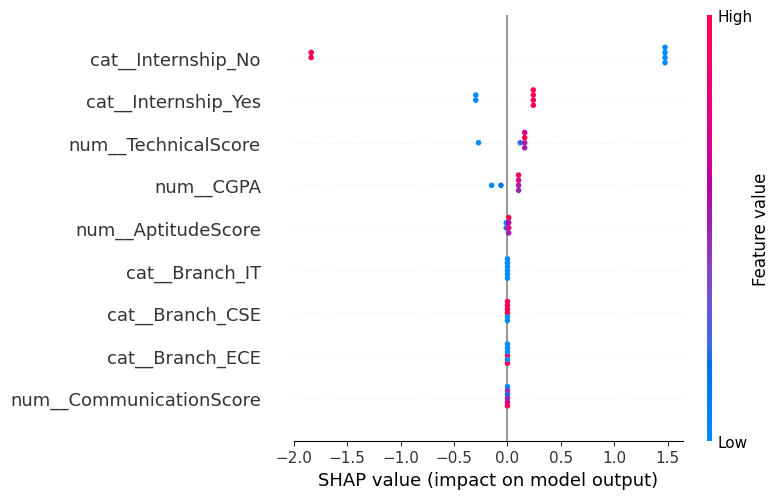

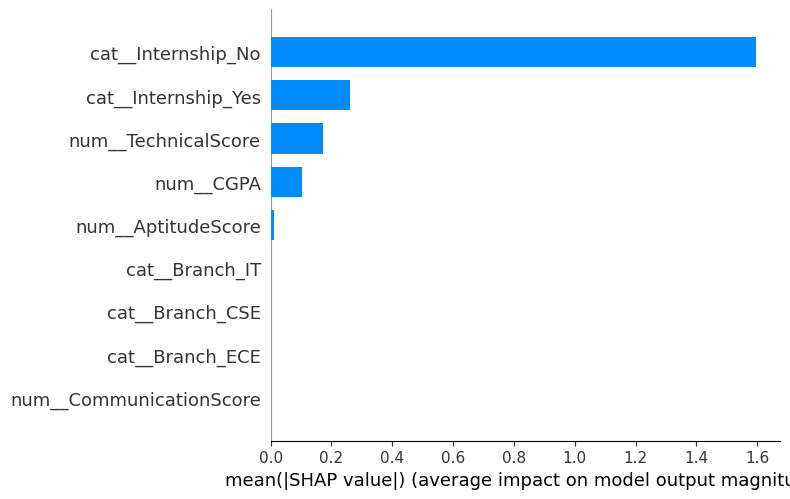



SESSION 8 ANALYSIS

ADABOOST:
- AdaBoost means Adaptive Boosting.
- It trains weak learners sequentially.
- More attention is given to incorrectly classified samples.
- Sample weights change during the boosting process.

GRADIENT BOOSTING:
- Builds trees sequentially.
- Each new tree tries to correct errors made by previous trees.
- It minimizes a loss function using gradient-based optimization.

XGBOOST:
- XGBoost is an optimized gradient boosting algorithm.
- It includes regularisation and efficient computation.
- Early stopping can stop training when validation performance
  stops improving.

EARLY STOPPING:
- Training is stopped when validation performance does not
  improve for a specified number of rounds.
- This can reduce unnecessary training and help prevent
  overfitting.

LIGHTGBM:
- LightGBM is a fast gradient boosting framework.
- It is designed for efficient training and can handle
  large datasets efficiently.

SHAP:
- SHAP explains individual model predictions.
- SHAP

In [1]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 8
# ================================================================
# TOPIC:
# BOOSTING ALGORITHMS
#
# Includes:
# 1. AdaBoost
# 2. Gradient Boosting Classifier
# 3. XGBoost
# 4. LightGBM
# 5. AdaBoost sample weights
# 6. XGBoost early stopping
# 7. LightGBM training time
# 8. SHAP feature importance / beeswarm
# 9. v1 vs v2 boosting comparison
# 10. boosting_benchmark() function
# ================================================================


# ----------------------------------------------------------------
# 1. INSTALL REQUIRED PACKAGES
# ----------------------------------------------------------------
# Colab normally has scikit-learn.
#
# XGBoost  -> Gradient boosting library
# LightGBM -> Gradient boosting library
# SHAP     -> Model explanation library
# ----------------------------------------------------------------

!pip -q install xgboost lightgbm shap


# ----------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings

warnings.filterwarnings("ignore")


# Scikit-learn

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)


# XGBoost

from xgboost import XGBClassifier


# LightGBM

from lightgbm import LGBMClassifier


# SHAP

import shap


# =================================================================
# 3. CREATE STUDENT PLACEMENT DATASET
# =================================================================
# No external dataset is used.
#
# The dataset is created directly inside Google Colab.
# =================================================================


data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'Internship': [
        'No', 'No', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No', 'No', 'No', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'No',
        'No', 'Yes', 'Yes', 'Yes', 'Yes'
    ],

    'Branch': [
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'CSE',
        'IT', 'CSE', 'ECE', 'CSE', 'IT',
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'CSE'
    ],

    'PlacementStatus': [
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Placed', 'Placed',
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed'
    ]
}


df = pd.DataFrame(data)


print("=" * 75)
print("STUDENT PLACEMENT DATASET")
print("=" * 75)

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# =================================================================
# 4. SEPARATE FEATURES AND TARGET
# =================================================================


X = df.drop(
    columns=['PlacementStatus']
)

y = df['PlacementStatus']


# =================================================================
# 5. CONVERT TARGET TO 0/1
# =================================================================
# XGBoost and LightGBM work conveniently with numeric targets.
#
# Not Placed -> 0
# Placed     -> 1
# =================================================================


y_numeric = y.map({

    'Not Placed': 0,

    'Placed': 1

})


# =================================================================
# 6. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# =================================================================


numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()


categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()


print("\n" + "=" * 75)
print("FEATURE TYPES")
print("=" * 75)

print("Numerical:")
print(numerical_cols)

print("\nCategorical:")
print(categorical_cols)


# =================================================================
# 7. ONE-HOT ENCODING
# =================================================================
# Boosting algorithms require numerical input.
#
# Categorical columns:
# Internship
# Branch
#
# are converted into numerical columns using One-Hot Encoding.
# =================================================================


preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            'passthrough',
            numerical_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)


# =================================================================
# 8. TRAIN / VALIDATION SPLIT
# =================================================================


X_train, X_val, y_train, y_val = train_test_split(

    X,
    y_numeric,

    test_size=0.2,

    random_state=42,

    stratify=y_numeric
)


print("\n" + "=" * 75)
print("TRAIN / VALIDATION SPLIT")
print("=" * 75)

print("Training samples:",
      len(X_train))

print("Validation samples:",
      len(X_val))


# =================================================================
# 9. TRANSFORM DATA
# =================================================================


X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_val_encoded = preprocessor.transform(
    X_val
)


# Convert sparse matrices to dense arrays

if hasattr(
    X_train_encoded,
    "toarray"
):

    X_train_encoded = (
        X_train_encoded.toarray()
    )

    X_val_encoded = (
        X_val_encoded.toarray()
    )


# Feature names after OHE

feature_names = (
    preprocessor
    .get_feature_names_out()
)


print("\nNumber of transformed features:",
      len(feature_names))


# =================================================================
# 10. ADA BOOST
# =================================================================
#
# AdaBoost = Adaptive Boosting.
#
# It gives more weight to incorrectly classified observations
# so later weak learners concentrate on difficult samples.
# =================================================================


ada_model = AdaBoostClassifier(

    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),

    n_estimators=50,

    learning_rate=0.5,

    random_state=42
)


# Train AdaBoost

ada_model.fit(
    X_train_encoded,
    y_train
)


# Predictions

ada_train_pred = ada_model.predict(
    X_train_encoded
)

ada_val_pred = ada_model.predict(
    X_val_encoded
)


# Accuracy

ada_train_acc = accuracy_score(
    y_train,
    ada_train_pred
)

ada_val_acc = accuracy_score(
    y_val,
    ada_val_pred
)


print("\n")
print("=" * 75)
print("ADABOOST")
print("=" * 75)

print("Train Accuracy:",
      ada_train_acc)

print("Validation Accuracy:",
      ada_val_acc)


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        ada_val_pred
    )
)


# =================================================================
# 11. ADA BOOST SAMPLE WEIGHTS
# =================================================================
#
# AdaBoost focuses more on incorrectly classified samples.
#
# estimator_errors_ stores the error of each weak learner.
# estimator_weights_ stores the importance of each weak learner.
#
# We also demonstrate how sample weights change during boosting
# using a small manual example.
# =================================================================


sample_weights = np.ones(
    len(X_train_encoded)
) / len(X_train_encoded)


print("\nInitial AdaBoost sample weight:")
print(sample_weights[:10])


# Manual demonstration of one AdaBoost round

weak_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)


weak_tree.fit(
    X_train_encoded,
    y_train,
    sample_weight=sample_weights
)


weak_prediction = weak_tree.predict(
    X_train_encoded
)


incorrect = (
    weak_prediction !=
    y_train.to_numpy()
)


weighted_error = np.sum(
    sample_weights * incorrect
)


if weighted_error < 1:

    alpha = 0.5 * np.log(
        (1 - weighted_error) /
        max(weighted_error, 1e-10)
    )


    # Increase weights for incorrectly classified samples

    new_weights = (
        sample_weights *
        np.exp(
            alpha * incorrect
        )
    )


    # Normalize

    new_weights = (
        new_weights /
        new_weights.sum()
    )


    print("\nWeighted Error:",
          weighted_error)

    print("Weak Learner Weight:",
          alpha)

    print("\nUpdated sample weights:")
    print(new_weights[:10])


# =================================================================
# 12. GRADIENT BOOSTING CLASSIFIER
# =================================================================
#
# Gradient Boosting builds trees sequentially.
#
# Each new tree attempts to correct errors made by previous trees.
# =================================================================


gb_model = GradientBoostingClassifier(

    n_estimators=100,

    learning_rate=0.05,

    max_depth=2,

    random_state=42
)


gb_model.fit(
    X_train_encoded,
    y_train
)


gb_val_pred = gb_model.predict(
    X_val_encoded
)


gb_val_acc = accuracy_score(
    y_val,
    gb_val_pred
)


print("\n")
print("=" * 75)
print("GRADIENT BOOSTING")
print("=" * 75)

print("Validation Accuracy:",
      gb_val_acc)


# =================================================================
# 13. XGBOOST
# =================================================================
#
# XGBoost = Extreme Gradient Boosting.
#
# It is an optimized gradient boosting implementation.
#
# eval_set allows us to monitor validation performance.
# =================================================================


xgb_model = XGBClassifier(

    n_estimators=300,

    max_depth=3,

    learning_rate=0.03,

    subsample=0.9,

    colsample_bytree=0.9,

    objective='binary:logistic',

    eval_metric='logloss',

    early_stopping_rounds=20,

    random_state=42
)


# Start timer

xgb_start = time.time()


# Train XGBoost

xgb_model.fit(

    X_train_encoded,

    y_train,

    eval_set=[
        (
            X_val_encoded,
            y_val
        )
    ],

    verbose=False
)


xgb_time = (
    time.time() -
    xgb_start
)


# Predictions

xgb_val_pred = (
    xgb_model
    .predict(
        X_val_encoded
    )
)


xgb_val_acc = accuracy_score(

    y_val,

    xgb_val_pred
)


print("\n")
print("=" * 75)
print("XGBOOST")
print("=" * 75)

print("Validation Accuracy:",
      xgb_val_acc)

print("Training Time:",
      round(xgb_time, 4),
      "seconds")


# =================================================================
# 14. XGBOOST EARLY STOPPING
# =================================================================
#
# Early stopping stops training when validation performance
# does not improve for a specified number of rounds.
#
# This helps prevent unnecessary training and can reduce
# overfitting.
# =================================================================


print("\nBest XGBoost iteration:")

print(
    getattr(
        xgb_model,
        "best_iteration",
        "Not available"
    )
)


# =================================================================
# 15. LIGHTGBM
# =================================================================
#
# LightGBM is another gradient boosting framework.
#
# We measure its training time.
# =================================================================


lgb_model = LGBMClassifier(

    n_estimators=100,

    learning_rate=0.05,

    max_depth=3,

    num_leaves=15,

    verbosity=-1,

    random_state=42
)


# Start timer

lgb_start = time.time()


# Train

lgb_model.fit(

    X_train_encoded,

    y_train
)


lgb_time = (
    time.time() -
    lgb_start
)


# Prediction

lgb_val_pred = (
    lgb_model
    .predict(
        X_val_encoded
    )
)


lgb_val_acc = accuracy_score(

    y_val,

    lgb_val_pred
)


print("\n")
print("=" * 75)
print("LIGHTGBM")
print("=" * 75)

print("Validation Accuracy:",
      lgb_val_acc)

print("Training Time:",
      round(lgb_time, 4),
      "seconds")


# =================================================================
# 16. boosting_benchmark() FUNCTION
# =================================================================
#
# This is the main function required in Session 8.
#
# It fits:
#
# AdaBoost
# Gradient Boosting
# XGBoost
# LightGBM
#
# It returns:
#
# Model
# val_accuracy
# train_time
#
# sorted by validation accuracy descending.
# =================================================================


def boosting_benchmark(

    X_train,
    y_train,
    X_val,
    y_val

):


    results = []


    # ------------------------------------------------------------
    # ADABOOST
    # ------------------------------------------------------------

    start = time.time()


    ada = AdaBoostClassifier(

        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),

        n_estimators=50,

        learning_rate=0.5,

        random_state=42
    )


    ada.fit(
        X_train,
        y_train
    )


    ada_prediction = ada.predict(
        X_val
    )


    ada_accuracy = accuracy_score(
        y_val,
        ada_prediction
    )


    ada_time = (
        time.time() -
        start
    )


    results.append({

        'Model':
        'AdaBoost',

        'val_accuracy':
        ada_accuracy,

        'train_time':
        ada_time
    })


    # ------------------------------------------------------------
    # GRADIENT BOOSTING
    # ------------------------------------------------------------

    start = time.time()


    gbc = GradientBoostingClassifier(

        n_estimators=100,

        learning_rate=0.05,

        max_depth=2,

        random_state=42
    )


    gbc.fit(
        X_train,
        y_train
    )


    gbc_prediction = gbc.predict(
        X_val
    )


    gbc_accuracy = accuracy_score(
        y_val,
        gbc_prediction
    )


    gbc_time = (
        time.time() -
        start
    )


    results.append({

        'Model':
        'Gradient Boosting',

        'val_accuracy':
        gbc_accuracy,

        'train_time':
        gbc_time
    })


    # ------------------------------------------------------------
    # XGBOOST
    # ------------------------------------------------------------

    start = time.time()


    xgb = XGBClassifier(

        n_estimators=200,

        max_depth=3,

        learning_rate=0.03,

        subsample=0.9,

        colsample_bytree=0.9,

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42
    )


    xgb.fit(
        X_train,
        y_train,
        verbose=False
    )


    xgb_prediction = xgb.predict(
        X_val
    )


    xgb_accuracy = accuracy_score(
        y_val,
        xgb_prediction
    )


    xgb_time = (
        time.time() -
        start
    )


    results.append({

        'Model':
        'XGBoost',

        'val_accuracy':
        xgb_accuracy,

        'train_time':
        xgb_time
    })


    # ------------------------------------------------------------
    # LIGHTGBM
    # ------------------------------------------------------------

    start = time.time()


    lgb = LGBMClassifier(

        n_estimators=100,

        learning_rate=0.05,

        max_depth=3,

        num_leaves=15,

        verbosity=-1,

        random_state=42
    )


    lgb.fit(
        X_train,
        y_train
    )


    lgb_prediction = lgb.predict(
        X_val
    )


    lgb_accuracy = accuracy_score(
        y_val,
        lgb_prediction
    )


    lgb_time = (
        time.time() -
        start
    )


    results.append({

        'Model':
        'LightGBM',

        'val_accuracy':
        lgb_accuracy,

        'train_time':
        lgb_time
    })


    # ------------------------------------------------------------
    # CREATE DATAFRAME
    # ------------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )


    # Sort by validation accuracy
    # from highest to lowest

    results_df = results_df.sort_values(

        by='val_accuracy',

        ascending=False
    )


    # Reset index

    results_df = (
        results_df
        .reset_index(drop=True)
    )


    return results_df


# =================================================================
# 17. RUN boosting_benchmark()
# =================================================================


benchmark_results = boosting_benchmark(

    X_train_encoded,

    y_train,

    X_val_encoded,

    y_val
)


print("\n")
print("=" * 80)
print("BOOSTING BENCHMARK")
print("=" * 80)

print(
    benchmark_results.to_string(
        index=False
    )
)


# =================================================================
# 18. V1 VS V2 BOOSTING COMPARISON
# =================================================================
#
# Version 1:
# Simple/default boosting configuration.
#
# Version 2:
# Tuned configuration using lower learning rate and more trees.
#
# This demonstrates how hyperparameter changes can affect
# validation performance.
# =================================================================


# -----------------------------
# V1
# -----------------------------

v1_model = GradientBoostingClassifier(

    n_estimators=50,

    learning_rate=0.1,

    max_depth=1,

    random_state=42
)


v1_model.fit(

    X_train_encoded,

    y_train
)


v1_prediction = v1_model.predict(

    X_val_encoded
)


v1_accuracy = accuracy_score(

    y_val,

    v1_prediction
)


# -----------------------------
# V2
# -----------------------------

v2_model = GradientBoostingClassifier(

    n_estimators=150,

    learning_rate=0.03,

    max_depth=2,

    random_state=42
)


v2_model.fit(

    X_train_encoded,

    y_train
)


v2_prediction = v2_model.predict(

    X_val_encoded
)


v2_accuracy = accuracy_score(

    y_val,

    v2_prediction
)


# Comparison DataFrame

version_df = pd.DataFrame({

    'Version': [
        'Boosting V1',
        'Boosting V2'
    ],

    'Validation Accuracy': [
        v1_accuracy,
        v2_accuracy
    ]
})


print("\n")
print("=" * 75)
print("BOOSTING V1 VS V2")
print("=" * 75)

print(
    version_df.to_string(
        index=False
    )
)


# =================================================================
# 19. V1 VS V2 BAR CHART
# =================================================================


plt.figure(
    figsize=(8, 5)
)


plt.bar(

    version_df['Version'],

    version_df['Validation Accuracy']
)


plt.ylabel(
    'Validation Accuracy'
)


plt.title(
    'Boosting V1 vs V2'
)


plt.ylim(
    0,
    1.1
)


plt.show()


# =================================================================
# 20. SHAP EXPLANATION
# =================================================================
#
# SHAP = SHapley Additive exPlanations.
#
# It explains how individual features contribute to predictions.
#
# A SHAP beeswarm plot shows:
#
# - Important features
# - Direction of their influence
# - Distribution of feature effects
# =================================================================


# Create SHAP TreeExplainer for XGBoost

explainer = shap.TreeExplainer(
    xgb_model
)


# Calculate SHAP values

shap_values = explainer.shap_values(
    X_val_encoded
)


# Beeswarm plot

print("\n")
print("=" * 75)
print("SHAP BEESWARM PLOT")
print("=" * 75)


shap.summary_plot(

    shap_values,

    X_val_encoded,

    feature_names=feature_names,

    show=True
)


# =================================================================
# 21. SHAP BAR PLOT
# =================================================================
#
# This gives an easier overall ranking of feature importance.
# =================================================================


shap.summary_plot(

    shap_values,

    X_val_encoded,

    feature_names=feature_names,

    plot_type='bar',

    show=True
)


# =================================================================
# 22. FINAL ANALYSIS
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 8 ANALYSIS")
print("=" * 80)

print("""
ADABOOST:
- AdaBoost means Adaptive Boosting.
- It trains weak learners sequentially.
- More attention is given to incorrectly classified samples.
- Sample weights change during the boosting process.

GRADIENT BOOSTING:
- Builds trees sequentially.
- Each new tree tries to correct errors made by previous trees.
- It minimizes a loss function using gradient-based optimization.

XGBOOST:
- XGBoost is an optimized gradient boosting algorithm.
- It includes regularisation and efficient computation.
- Early stopping can stop training when validation performance
  stops improving.

EARLY STOPPING:
- Training is stopped when validation performance does not
  improve for a specified number of rounds.
- This can reduce unnecessary training and help prevent
  overfitting.

LIGHTGBM:
- LightGBM is a fast gradient boosting framework.
- It is designed for efficient training and can handle
  large datasets efficiently.

SHAP:
- SHAP explains individual model predictions.
- SHAP values show how features contribute to predictions.
- A beeswarm plot displays the distribution and importance
  of feature contributions.

V1 VS V2:
- Different boosting hyperparameters were compared.
- Number of estimators, learning rate and tree depth can
  influence model performance.

BENCHMARK:
- AdaBoost, Gradient Boosting, XGBoost and LightGBM were
  trained and compared.
- Validation accuracy and training time were recorded.
""")


# =================================================================
# 23. FINAL PRACTICAL SUMMARY
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 8 ML PRACTICAL COMPLETED")
print("=" * 80)

print("""
Implemented:

1. AdaBoost.
2. AdaBoost sample-weight demonstration.
3. Gradient Boosting Classifier.
4. XGBoost.
5. XGBoost early stopping.
6. LightGBM.
7. LightGBM training-time measurement.
8. SHAP explanation.
9. SHAP beeswarm plot.
10. Boosting V1 vs V2.
11. boosting_benchmark() function.
12. Validation accuracy comparison.
13. Training-time comparison.
14. Final analysis and viva preparation.
""")